# RNN, LSTM, and GRU for Text Generation
## AIAT 122 – Deep Learning

## Learning objectives
- Build a character-level LSTM for next-character prediction.
- Train on a short text and generate a sample sequence.

**Where is this used in real life?** Autocomplete, simple chatbots, and creative writing tools often use RNN/LSTM/GRU. **We use an LSTM for text generation** instead of a plain feedforward net because **order matters** in text; the LSTM processes one character at a time and keeps a hidden state so it can learn sequences.

**Prerequisites:** Basic TensorFlow/Keras. If TensorFlow import fails, see DOCS/COLAB_SETUP.md.

## Short theory
- **Character-level generation:** Model predicts the next character given previous characters.
- **LSTM** has gates (forget, input, output) that help it remember long-range dependencies better than a simple RNN.
- **Training:** Input = sequence of chars, target = next char; we use categorical cross-entropy.
- **Generation:** Feed a seed string, sample next char, append, repeat.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).


## Inputs & Outputs
**Inputs:** TensorFlow/Keras, a short training text (included in the notebook).  
**Dataset:** Built-in — short text included in notebook (character-level LSTM; no external download).  
**Outputs:** Trained LSTM, training loss curve, and a short generated character sequence. Run time: under ~5 min (few epochs, small text).


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
print(f'PyTorch {torch.__version__}')
print('✅ Ready. Using PyTorch LSTM for character-level text generation.')

PyTorch 2.13.0
✅ Ready. Using PyTorch LSTM for character-level text generation.


### Step 1: Prepare text and character mapping

In [2]:
# Small text corpus — character-level LSTM predicts the next character
text = 'the quick brown fox jumps over the lazy dog ' * 6
chars     = sorted(set(text))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
vocab_size  = len(chars)
seq_len     = 20
print('Vocab:', vocab_size, 'chars  |  Text length:', len(text))

# Build (X, y) pairs — each X is seq_len chars, y is the next char
X_idx, y_idx = [], []
for i in range(len(text) - seq_len):
    X_idx.append([char_to_idx[c] for c in text[i : i + seq_len]])
    y_idx.append(char_to_idx[text[i + seq_len]])

X_tensor = torch.tensor(X_idx, dtype=torch.long)   # (N, seq_len)
y_tensor = torch.tensor(y_idx, dtype=torch.long)    # (N,)
print('X shape:', X_tensor.shape, '  y shape:', y_tensor.shape)

Vocab: 27 chars  |  Text length: 264
X shape: torch.Size([244, 20])   y shape: torch.Size([244])


### Step 2: Build sequences and LSTM model, train (10 epochs)

In [3]:
# Define an LSTM-based character language model
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm  = nn.LSTM(embed_dim, hidden, batch_first=True)
        self.fc    = nn.Linear(hidden, vocab_size)
    def forward(self, x):
        e = self.embed(x)             # (batch, seq_len, embed_dim)
        out, _ = self.lstm(e)          # (batch, seq_len, hidden)
        return self.fc(out[:, -1, :])  # predict from last timestep

model     = CharLSTM(vocab_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-3)

# Training loop (20 epochs, batch_size=64)
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
ds     = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(ds, batch_size=64, shuffle=True)
losses = []
for epoch in range(20):
    model.train(); epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(loader))
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:>2}: loss={losses[-1]:.4f}')

Epoch  5: loss=2.4525
Epoch 10: loss=1.0599
Epoch 15: loss=0.3137
Epoch 20: loss=0.1227


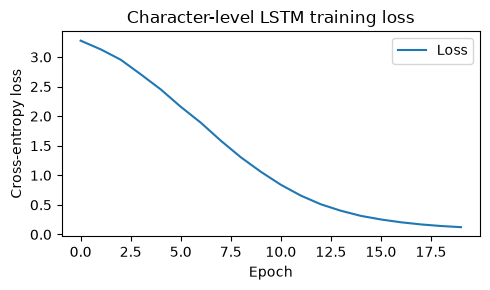

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3))
plt.plot(losses, label='Loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss')
plt.title('Character-level LSTM training loss')
plt.legend(); plt.tight_layout(); plt.show()

In [5]:
# Generate 40 characters using the trained LSTM
def generate(model, seed_text, n_chars=40, temperature=1.0):
    model.eval()
    generated = seed_text
    context = [char_to_idx.get(c, 0) for c in seed_text[-seq_len:]]
    for _ in range(n_chars):
        x = torch.tensor([context], dtype=torch.long)
        with torch.no_grad():
            logits = model(x)[0] / temperature
        probs = torch.softmax(logits, dim=0).numpy()
        next_idx = np.random.choice(len(probs), p=probs)
        generated += idx_to_char[next_idx]
        context = context[1:] + [next_idx]
    return generated

seed = text[:seq_len]
print('Seed:', repr(seed))
print('Generated:', repr(generate(model, seed, n_chars=40)))

Seed: 'the quick brown fox '
Generated: 'the quick brown fox juis bvrow fox jumps over the quuks bog '


## 🌍 Real-World Worked Example — Character-Level Text Generator

**Industry context:**
- GitHub Copilot generates code character by character using GPT-4
- ChatGPT predicts the next token based on all previous context
- Autocomplete on your phone uses a smaller version of the same idea

We build a **character-level language model** that learns to generate text token by token — the exact mechanism behind all LLMs.

In [6]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]

SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nThis is exactly how ChatGPT generates text — one token at a time.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or noteu ar as wasea dhe arslac shoc shatra fles hothe sand to sace and the hea sains ta ce arsumatio so f

This is exactly how ChatGPT generates text — one token at a time.


## 🧩 Mini-exercise

**Try it:** Change the seed string and generate again. Or increase the number of characters to generate and see when the output becomes incoherent.

---

## Summary
**What you did:** Prepared character-level sequences, built an LSTM, trained it for next-character prediction, and generated a short sequence from a seed.

**In real life you'd also:** Use word-level models, larger corpora, and sampling (temperature) for more varied text.

**The main idea:** RNN/LSTM process text step by step and keep hidden state so they can learn and generate sequences.

**Next:** `09_transformer_models_bert_gpt_nlp.ipynb` shows BERT and GPT for understanding and generation.

## 📚 References & Further Reading

**Papers:**
- Radford et al. (2019) — [GPT-2: Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- Brown et al. (2020) — [GPT-3](https://arxiv.org/abs/2005.14165)

**Interactive:**
- [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT) — build GPT in 300 lines
- [The Unreasonable Effectiveness of RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

**State-of-the-Art:** GPT-4, Claude 3.5, Gemini 1.5 — all trained on trillions of tokens with transformer decoders.